# Healthcare Appointment No-Show Analysis

## Business Problem
Healthcare providers lose time, money, and operational efficiency when patients miss scheduled appointments.

This project analyzes patient appointment data to identify:
- factors affecting no-shows
- patient behavior patterns
- operational inefficiencies
- opportunities to reduce missed appointments

The goal is to derive actionable insights using data analysis and visualization.

## Loading the Dataset

The dataset contains information about medical appointments, patient demographics, health conditions, and appointment attendance.

Each row represents one medical appointment.

### Data quality and analysis objectives
- Confirm that the dataset is complete and understand any missing values
- Identify duplicate or invalid appointments
- Convert date fields and derive calendar features
- Engineer business-relevant metrics for no-show analysis
- Remove invalid cases such as negative age or impossible scheduling logic


- Confirm missing values and duplicate records- Convert datetime fields and create useful calendar features

In [1]:
import pandas as pd
import matplotlib.pyplot as plt     
df = pd.read_csv('../data/raw/KaggleV2-May-2016.csv')

In [2]:
import seaborn as sns

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
df.shape

(110527, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [7]:
missing_counts = df.isnull().sum()
print('Missing values by column:')
print(missing_counts[missing_counts > 0] if missing_counts.any() else 'No missing values found.')

duplicate_count = df.duplicated().sum()
print('\nDuplicate rows detected:', duplicate_count)
if duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Dropped duplicate rows.')
else:
    print('No duplicate rows found.')

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df['NoShowFlag'] = df['No-show'].map({'No': 0, 'Yes': 1})

df['ScheduledWeekday'] = df['ScheduledDay'].dt.day_name()
df['AppointmentWeekday'] = df['AppointmentDay'].dt.day_name()

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[-1, 18, 35, 50, 65, 115],
    labels=[
        'Child / Young Adult',
        'Young Adult',
        'Adult',
        'Senior',
        'Elder'
    ],
    include_lowest=True
)

invalid_age_count = (df['Age'] < 0).sum()
print('\nInvalid age records:', invalid_age_count)
df = df[df['Age'] >= 0].copy()

Missing values by column:
No missing values found.

Duplicate rows detected: 0
No duplicate rows found.

Invalid age records: 1


# Feature Engineering: Waiting Days and Appointment Segments

A new feature called `WaitingDays` is created to calculate the number of days between:
- appointment scheduling date
- actual appointment date

This feature is important because longer waiting times may increase the probability of missed appointments.

We also derive additional analytic dimensions that are useful for dashboards and business planning:
- `NoShowFlag` as a numeric indicator for rate calculations
- `ScheduledWeekday` and `AppointmentWeekday` for appointment day patterns
- `AgeGroup` for cohort comparisons and customer segmentation

In [8]:
df['WaitingDays'] = (
    df['AppointmentDay'] - df['ScheduledDay']
).dt.days
invalid_waiting = (df['WaitingDays'] < 0).sum()
print('Invalid waiting-days records:', invalid_waiting)

Invalid waiting-days records: 38567


In [9]:
df = df[df['WaitingDays'] >= 0].copy()
print('Remaining records after invalid waiting-day removal:', len(df))

Remaining records after invalid waiting-day removal: 71959


# Removing Invalid Waiting Days

Some records contain negative waiting days, meaning:
- appointment date occurred before scheduling date

These records are logically invalid and are removed to improve data quality.

This cleaned dataset is now better suited for reliable no-show analysis and operational reporting.

In [10]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,NoShowFlag,WaitingDays
count,7.195900e+04,7.195900e+04,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000
mean,1.452606e+14,5.655042e+06,38.502564,0.092706,0.208897,0.074723,0.025320,0.020025,0.493086,0.285190,14.642018
std,2.535667e+14,7.472189e+04,22.925421,0.290021,0.406523,0.262946,0.157096,0.154072,0.499956,0.451508,16.494334
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.968099e+12,5.617796e+06,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,2.991891e+13,5.661165e+06,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
75%,9.371660e+13,5.707178e+06,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,21.000000
max,9.999320e+14,5.784985e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,178.000000


## Data Quality Summary

The dataset has been cleaned to remove invalid records and preserve only logically consistent appointments. The next section uses the cleaned data for analytical insights and operational patterns.

In [11]:
print('No-show rate after cleaning: {:.2f}%'.format(df['NoShowFlag'].mean() * 100))
print('\nAppointment weekday no-show rate (%):')
weekday_rate = df.groupby('AppointmentWeekday')['NoShowFlag'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).mul(100).round(1)
print(weekday_rate)

neighborhood_rate = df.groupby('Neighbourhood')['NoShowFlag'].mean().mul(100).sort_values(ascending=False).head(10).round(2)
print('\nTop 10 neighbourhoods by no-show rate:')
print(neighborhood_rate)

No-show rate after cleaning: 28.52%

Appointment weekday no-show rate (%):
AppointmentWeekday
Monday       30.2
Tuesday      28.7
Wednesday    27.1
Thursday     27.3
Friday       29.4
Saturday     29.0
Sunday        NaN
Name: NoShowFlag, dtype: float64

Top 10 neighbourhoods by no-show rate:
Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    100.00
GURIGICA                        38.37
JESUS DE NAZARETH               37.49
ITARARÉ                         36.50
HORTO                           35.96
SANTOS DUMONT                   34.89
SANTA CLARA                     33.86
SANTA CECÍLIA                   33.52
ARIOVALDO FAVALESSA             32.57
ILHA DO PRÍNCIPE                32.53
Name: NoShowFlag, dtype: float64


In [ ]:
df['WaitingCategory'] = pd.cut(
    df['WaitingDays'],
    bins=[-1, 0, 3, 7, 15, 30, 180],
    labels=[
        'Same Day',
        '1-3 Days',
        '4-7 Days',
        '8-15 Days',
        '16-30 Days',
        '30+ Days'
    ]
)

In [13]:
pd.crosstab(
    df['WaitingCategory'],
    df['No-show'],
    normalize='index'
) * 100

No-show,No,Yes
WaitingCategory,,
Same Day,78.649530,21.350470
1-3 Days,76.430315,23.569685
4-7 Days,73.529412,26.470588
8-15 Days,68.842634,31.157366
16-30 Days,67.327312,32.672688
30+ Days,66.979188,33.020812


In [14]:
df['No-show'].value_counts(normalize=True) * 100

No-show
No     71.480982
Yes    28.519018
Name: proportion, dtype: float64

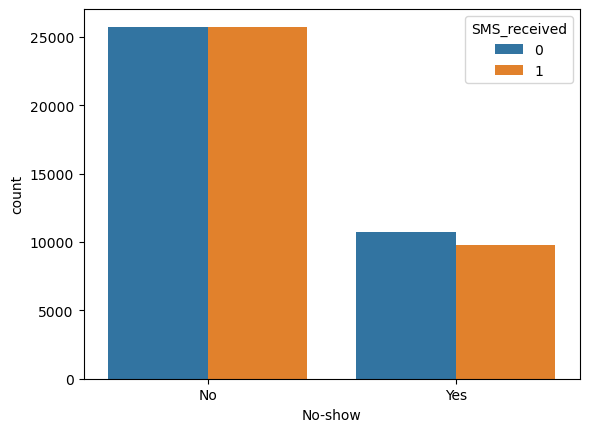

In [15]:
sns.countplot(x="No-show",hue="SMS_received",data=df)
plt.show()

In [16]:
pd.crosstab(df['SMS_received'], df['No-show'])

No-show,No,Yes
SMS_received,,
0,25739,10738
1,25698,9784


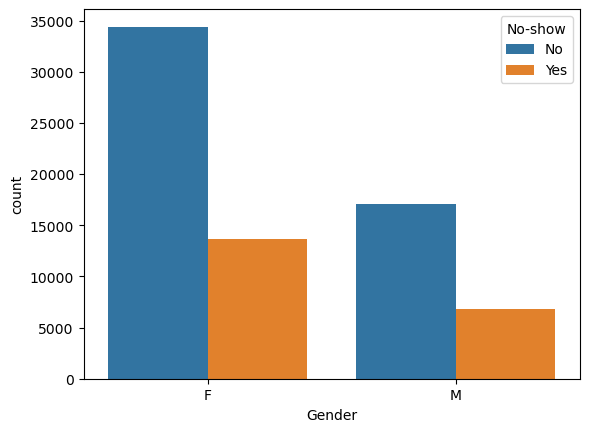

In [17]:
sns.countplot(x="Gender",hue="No-show",data=df)
plt.show()

<Axes: xlabel='No-show', ylabel='Age'>

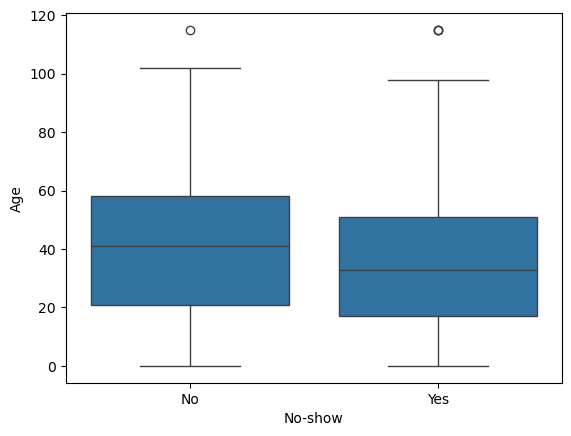

In [18]:
sns.boxplot(x="No-show",y="Age",data=df)

In [19]:
pd.crosstab(
    df['Scholarship'],
    df['No-show'],
    normalize='index'
) * 100

No-show,No,Yes
Scholarship,,
0,72.140363,27.859637
1,65.027732,34.972268


Patients receiving financial assistance demonstrated slightly different appointment attendance behavior compared to non-assisted patients.

This finding suggests `Scholarship` should be included in dashboards as a segmentation variable, while also being evaluated with other demographic and behavioral factors.

In [20]:
pd.crosstab(
    df['Diabetes'],
    df['No-show'],
    normalize='index'
) * 100

No-show,No,Yes
Diabetes,,
0,71.193416,28.806584
1,75.041845,24.958155


Patients with chronic conditions such as diabetes tended to attend appointments more consistently.

This finding is useful for operations: patients with ongoing chronic care needs are often more likely to keep appointments, so targeting reminder interventions to other groups may yield better impact.

In [21]:
df.groupby('No-show')['WaitingDays'].mean()

No-show
No     14.013142
Yes    16.218254
Name: WaitingDays, dtype: float64


Patients who missed appointments had a higher average waiting time compared to patients who attended their appointments.

This suggests that longer waiting periods may contribute to increased no-show behavior. Reducing appointment waiting time could potentially improve patient attendance rates.

In [22]:
pd.crosstab(
    df['WaitingCategory'],
    df['No-show'],
    normalize='index'
) * 100

No-show,No,Yes
WaitingCategory,,
Same Day,78.649530,21.350470
1-3 Days,76.430315,23.569685
4-7 Days,73.529412,26.470588
8-15 Days,68.842634,31.157366
16-30 Days,67.327312,32.672688
30+ Days,66.979188,33.020812




A clear relationship was observed between waiting time and appointment attendance.

Patients with shorter waiting periods showed lower no-show percentages, while patients waiting longer for appointments were significantly more likely to miss them.

The no-show rate increased steadily from approximately 21% for same-day appointments to over 33% for appointments scheduled after 30 or more days.

This suggests that reducing appointment waiting time could improve patient attendance and operational efficiency.



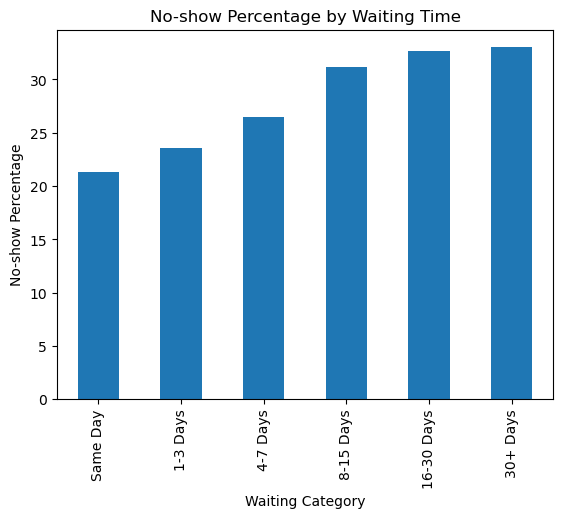

In [23]:
waiting_analysis = pd.crosstab(
    df['WaitingCategory'],
    df['No-show'],
    normalize='index'
) * 100

waiting_analysis['Yes'].plot(kind='bar')

plt.title('No-show Percentage by Waiting Time')
plt.xlabel('Waiting Category')
plt.ylabel('No-show Percentage')

plt.show()

### Final recommendations
- Use shorter wait windows for high-risk patient segments.
- Monitor no-show patterns by weekday and neighbourhood.
- Build dashboard filters for `WaitingCategory`, `AgeGroup`, `ScheduledWeekday`, and `NoShowFlag` to support actionable scheduling decisions.
- Prioritize follow-up communication for appointments booked more than two weeks in advance.

In [26]:
# Export cleaned data for downstream analysis and dashboards

# The cleaned dataset includes useful dashboard-ready fields such as:
# - NoShowFlag
# - WaitingDays
# - WaitingCategory
# - ScheduledWeekday
# - AppointmentWeekday
# - AgeGroup
# - Neighbourhood

df.to_csv("healthcare_cleaned_final.csv", index=False)